<a href="https://colab.research.google.com/github/dagudelo30/Series-de-tiempo---Javeriana-Cali/blob/main/hwt/suavización_exponencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pronósticos basados en series de tiempo 

## Diego Fernando Agudelo
## Universidad Javeriana-Cali
## diegoagudelo30@gmail.com



## **1. Carga de paquetes**

In [1]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


Este documento presenta una breve introducción a la construcción de objetos de series de tiempo y el cálculo de pronósticos con modelos de suavización.

Para este ejercicio emplearemos la información disponible en el archivo datosEmpleo.xlsx. En ese archivo econtrarán la tasa de desempleo mensual de las 13 principales ciudades en Colombia (TD_13ciudades). El archivo también contiene series mensuales para las 13 principales ciudades de Colombia el número de ocupados en miles de personas (Ocupados), los desocupados (Desocupados) y los inactivos (Inactivos).

## **2. Carga de datos**

Nuestra primera tarea será leer el archivo de Excel. Para eso podemos emplear el paquete Pandas. Carguemos los datos en un objeto que denominaremos data.

In [2]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

A continuación se gráfica la tasa de desempleo.



(222, 4)


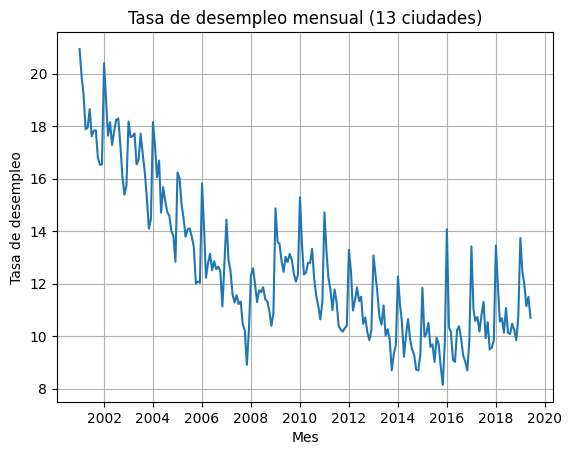

In [4]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("Tasa de desempleo mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Tasa de desempleo")
plt.plot(data[["TD_13ciudades"]])
plt.grid()
plt.show()

## **3. Pronosticando metodos de suavización**

Antes de continuar es importante guardar una parte de la muestra para evaluar el comportamiento de los modelos por fuera de muestra (out-of-sample). Guardemos un año de datos.

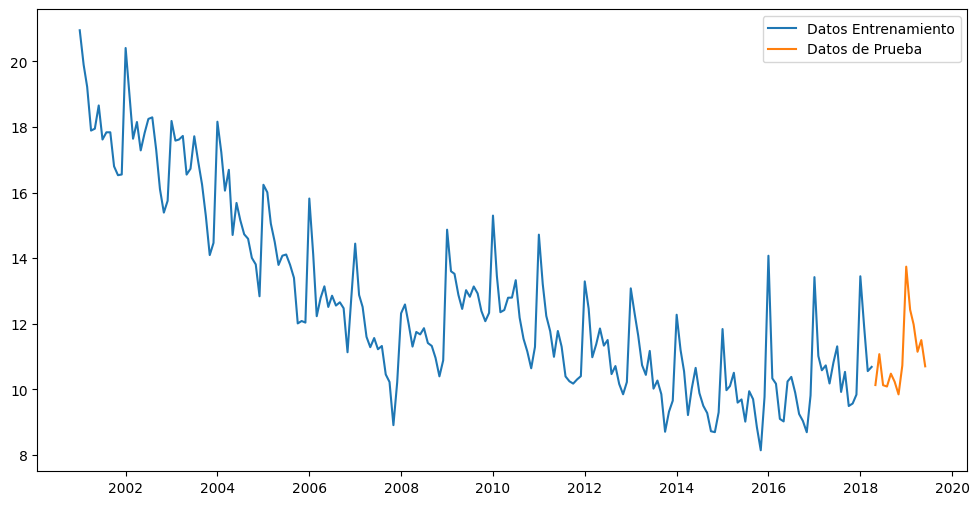

In [6]:
train_len = 208
train_td = data[["TD_13ciudades"]][:train_len]
test_td = data[["TD_13ciudades"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

In [7]:
train_td

,TD_13ciudades
mes,
2001-01-01,20.946380
2001-02-01,19.894213
2001-03-01,19.221565
2001-04-01,17.888575
2001-05-01,17.945654
...,...
2017-12-01,9.837395
2018-01-01,13.446245
2018-02-01,11.874973


In [8]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


### **3.1 Suavizacion Exponencial Simple**

In [9]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add")#,trend="add",seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds = pd.concat([limits, conf_forecast], axis = 1)
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

            Point_forecast  lower_95   upper_95
2018-05-01       10.959788  8.650409  13.269166
2018-06-01       10.959788  8.505555  13.414021
2018-07-01       10.959788  8.368785  13.550790
2018-08-01       10.959788  8.238882  13.680693
2018-09-01       10.959788  8.114905  13.804671
2018-10-01       10.959788  7.996109  13.923467
2018-11-01       10.959788  7.881895  14.037681
2018-12-01       10.959788  7.771770  14.147806
2019-01-01       10.959788  7.665324  14.254252
2019-02-01       10.959788  7.562212  14.357364
2019-03-01       10.959788  7.462138  14.457438
2019-04-01       10.959788  7.364848  14.554727
2019-05-01       10.959788  7.270124  14.649452
2019-06-01       10.959788  7.177770  14.741805


c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


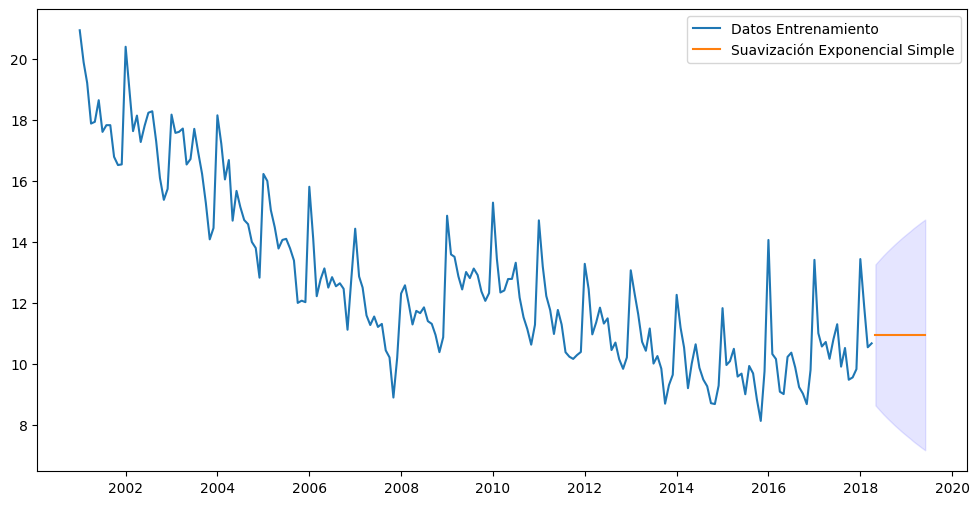

In [10]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds['Point_forecast'],label="Suavización Exponencial Simple")
plt.fill_between(preds.index ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En esta caso el α estimado es 0.3596639.Y el RMSE en la muestra de evaluación es 1.05

In [11]:
ets_result.alpha

0.35969945082396537

In [12]:
rmse = np.sqrt(mean_squared_error(test_td,point_forecast ))
print(rmse)

1.0532673907516774


### **3.2 Suavizacion Exponencial Lineal (Holt)**

In [13]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="mul",trend="mul")#,seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_holt = pd.concat([limits, conf_forecast], axis = 1)
preds_holt.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_holt)

            Point_forecast  lower_95   upper_95
2018-05-01       10.660588  8.631688  12.801353
2018-06-01       10.632891  8.446741  12.769005
2018-07-01       10.605266  8.402605  12.799954
2018-08-01       10.577713  8.490329  12.872343
2018-09-01       10.550231  8.563715  13.019526
2018-10-01       10.522821  8.436181  12.733728
2018-11-01       10.495481  8.255672  12.638657
2018-12-01       10.468213  8.288392  12.891170
2019-01-01       10.441016  8.257420  12.835207
2019-02-01       10.413889  8.165198  12.811793
2019-03-01       10.386833  8.185257  12.583112
2019-04-01       10.359848  8.127148  12.761234
2019-05-01       10.332932  8.072441  12.929898
2019-06-01       10.306086  8.081631  13.005774


c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


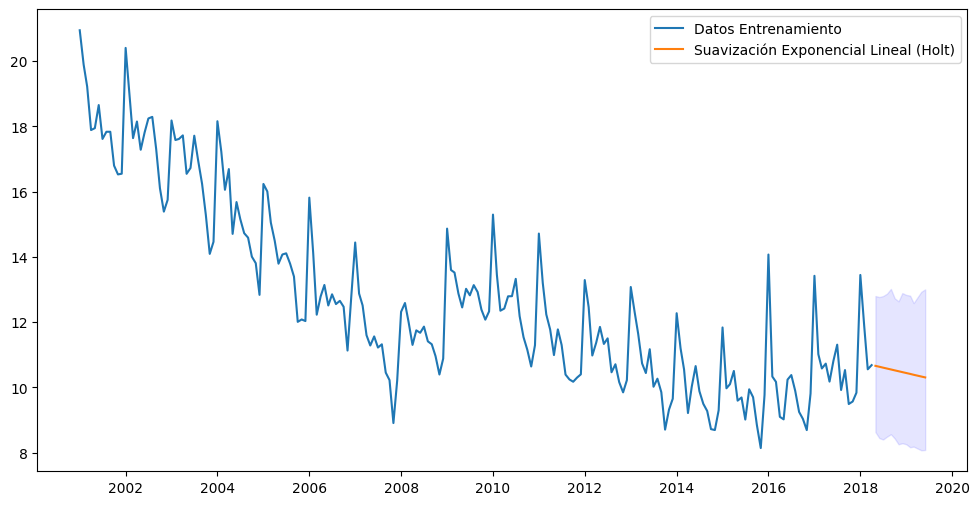

In [14]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_holt['Point_forecast'],label="Suavización Exponencial Lineal (Holt)")
plt.fill_between(preds_holt.index ,preds_holt['lower_95'], preds_holt['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En esta caso el α estimado es 0.17153975893378887 y el β estimado es 1.7153975893378887$^{-5}$. Y el RMSE en la muestra de evaluación es 1.22814498296009.

In [18]:
print(ets_result.alpha,ets_result.beta)

0.1715393694055197 1.715393694055197e-05


In [17]:
rmse_holt = np.sqrt(mean_squared_error(test_td,preds_holt['Point_forecast']))
print(rmse_holt)

1.22814498296009


### **3.3 Suavizacion Exponencial Lineal de Winters (Holt-Winters)**

In [19]:
# Build model
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add",trend="add",seasonal="add" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_add = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

            Point_forecast   lower_95   upper_95
2018-05-01       10.297375   9.251564  11.343187
2018-06-01       10.674323   9.532332  11.816314
2018-07-01       10.565101   9.334408  11.795795
2018-08-01       10.226586   8.913151  11.540021
2018-09-01        9.946359   8.555079  11.337638
2018-10-01        9.282620   7.817612  10.747628
2018-11-01        8.875131   7.339918  10.410345
2018-12-01        9.376558   7.774200  10.978917
2019-01-01       12.534203  10.867389  14.201017
2019-02-01       11.193061   9.464181  12.921941
2019-03-01       10.434222   8.645416  12.223028
2019-04-01       10.158458   8.311658  12.005258
2019-05-01        9.827779   7.924727  11.730832
2019-06-01       10.204727   8.247041  12.162413


c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


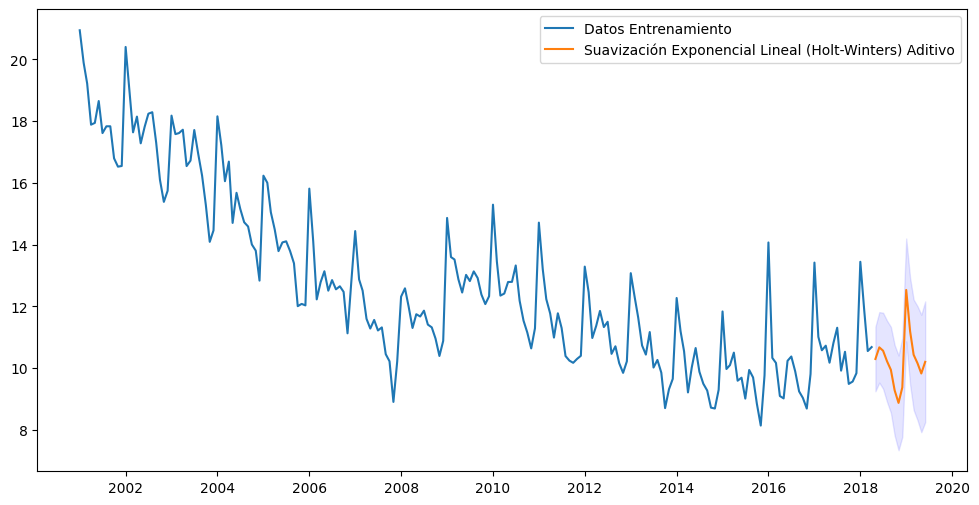

In [20]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Aditivo")
plt.fill_between(preds_hw_add.index ,preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [21]:
print(ets_result.alpha,ets_result.beta,ets_result.gamma)

0.4385788591267127 4.385788591267127e-05 5.6142114087328735e-05


In [22]:
rmse_hw_add = np.sqrt(mean_squared_error(test_td,preds_hw_add['Point_forecast']))
print(rmse_hw_add)

0.9893635516442755


In [23]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add",trend=None,seasonal="mul" , )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_mul = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

            Point_forecast   lower_95   upper_95
2018-05-01       10.433036   9.316655  11.538286
2018-06-01       10.981856   9.782254  12.090123
2018-07-01       10.779516   9.513526  12.043866
2018-08-01       10.380956   9.012029  11.749733
2018-09-01       10.300534   8.891712  11.641392
2018-10-01        9.708898   8.196997  11.152746
2018-11-01        9.565507   7.986178  11.033846
2018-12-01       10.265135   8.571947  11.927851
2019-01-01       13.399531  11.251371  15.524083
2019-02-01       11.447407   9.579448  13.402193
2019-03-01       10.843306   8.819700  12.707781
2019-04-01       10.618172   8.634554  12.504602
2019-05-01       10.433036   8.471032  12.378804
2019-06-01       10.981856   8.710124  13.095164


c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


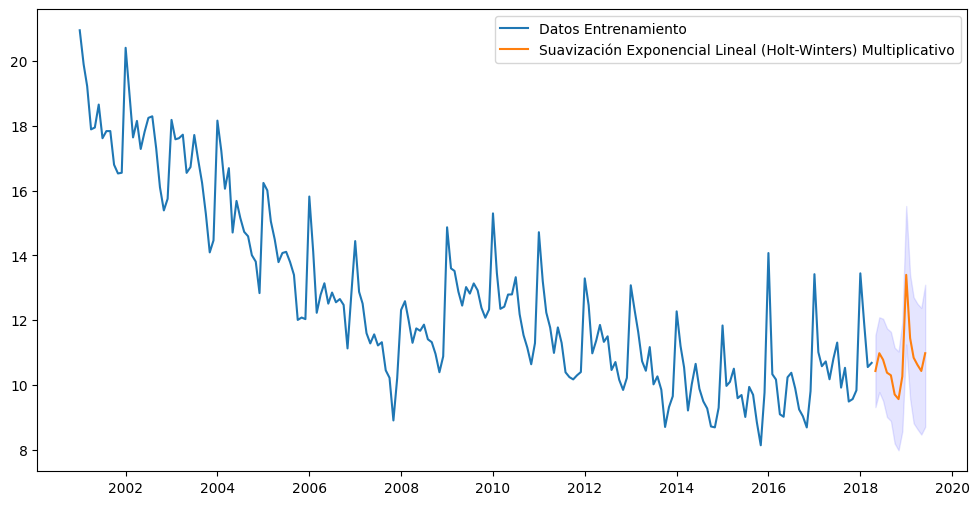

In [24]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_mul['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Multiplicativo")
plt.fill_between(preds_hw_mul.index ,preds_hw_mul['lower_95'], preds_hw_mul['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [25]:
print(ets_result.alpha,ets_result.gamma)

0.43149852724451526 0.16097100344659288


In [26]:
rmse_hw_mul = np.sqrt(mean_squared_error(test_td,preds_hw_mul['Point_forecast']))
print(rmse_hw_mul)

0.601249106566862


## **4. Pronosticando con todo el data set**

In [28]:
final_model = ETSModel(endog=data["TD_13ciudades"],error="add",trend=None,seasonal="mul")
final_model_fit = final_model.fit_constrained({'smoothing_level': 0.43149852724451526,'smoothing_seasonal':0.16097100344659288})

print(final_model_fit.alpha)
print(final_model_fit.gamma)


0.43149852724451526
0.16097100344659288


c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [29]:
point_forecast=final_model_fit.forecast(6)

ci = final_model_fit.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_final= pd.concat([limits, conf_forecast], axis = 1)
preds_final.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_final)

            Point_forecast  lower_95   upper_95
2019-07-01       11.046643  9.942649  12.236548
2019-08-01       10.739259  9.549072  12.056542
2019-09-01       10.735391  9.482439  12.006259
2019-10-01       10.144408  8.805910  11.496054
2019-11-01        9.914408  8.612051  11.490303
2019-12-01       10.658186  9.061568  12.431729


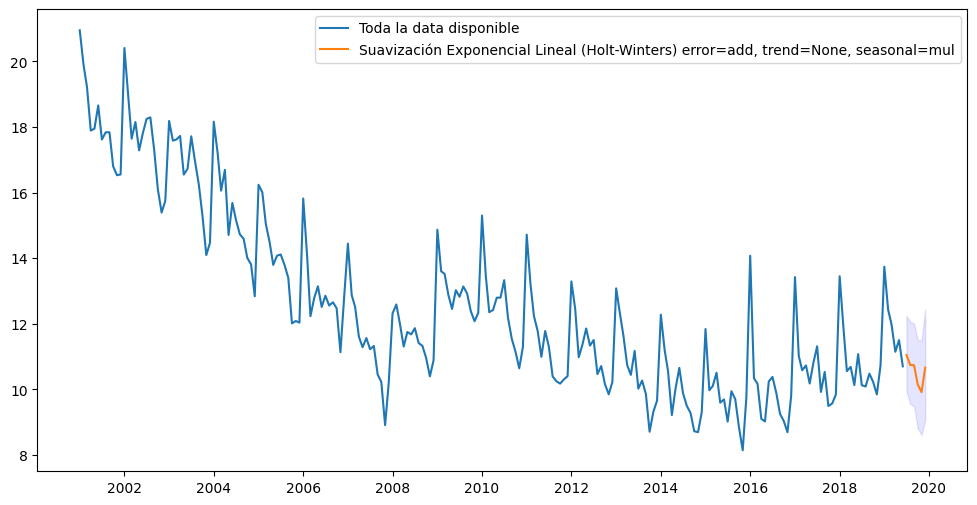

In [35]:
fig = plt.figure(figsize=(12, 6))
plt.plot(data["TD_13ciudades"],label="Toda la data disponible")
plt.plot(preds_final['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) error=add, trend=None, seasonal=mul")
plt.fill_between(preds_final.index ,preds_final['lower_95'], preds_final['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

## **5. Ejercicio en Clase: Pronóstico de Ocupados**

**Objetivo**: Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encontrar el mejor pronóstico para los próximos 6 meses mediante comparación rigurosa de tres variantes de suavización exponencial, validando con protocolo train/test de 6 periodos.

### 5.1 Descripción de la Base de Datos - Variable "Ocupados"

DESCRIPCIÓN DE LA BASE DE DATOS - VARIABLE 'OCUPADOS'

Período de datos: 2001-01-01 a 2019-06-01
Total de observaciones: 222
Frecuencia: Mensual

Estadísticas descriptivas:
           Ocupados
count    222.000000
mean    9160.852009
std     1295.492800
min     6923.604000
25%     7971.103000
50%     9139.064500
75%    10458.510250
max    11037.199000


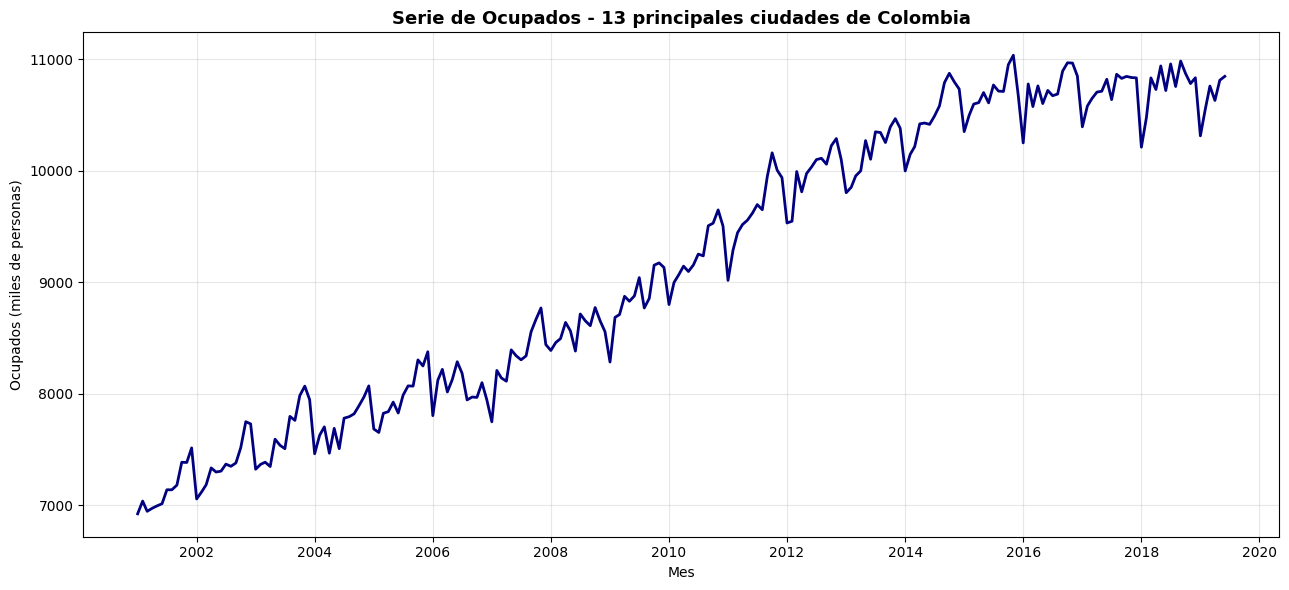

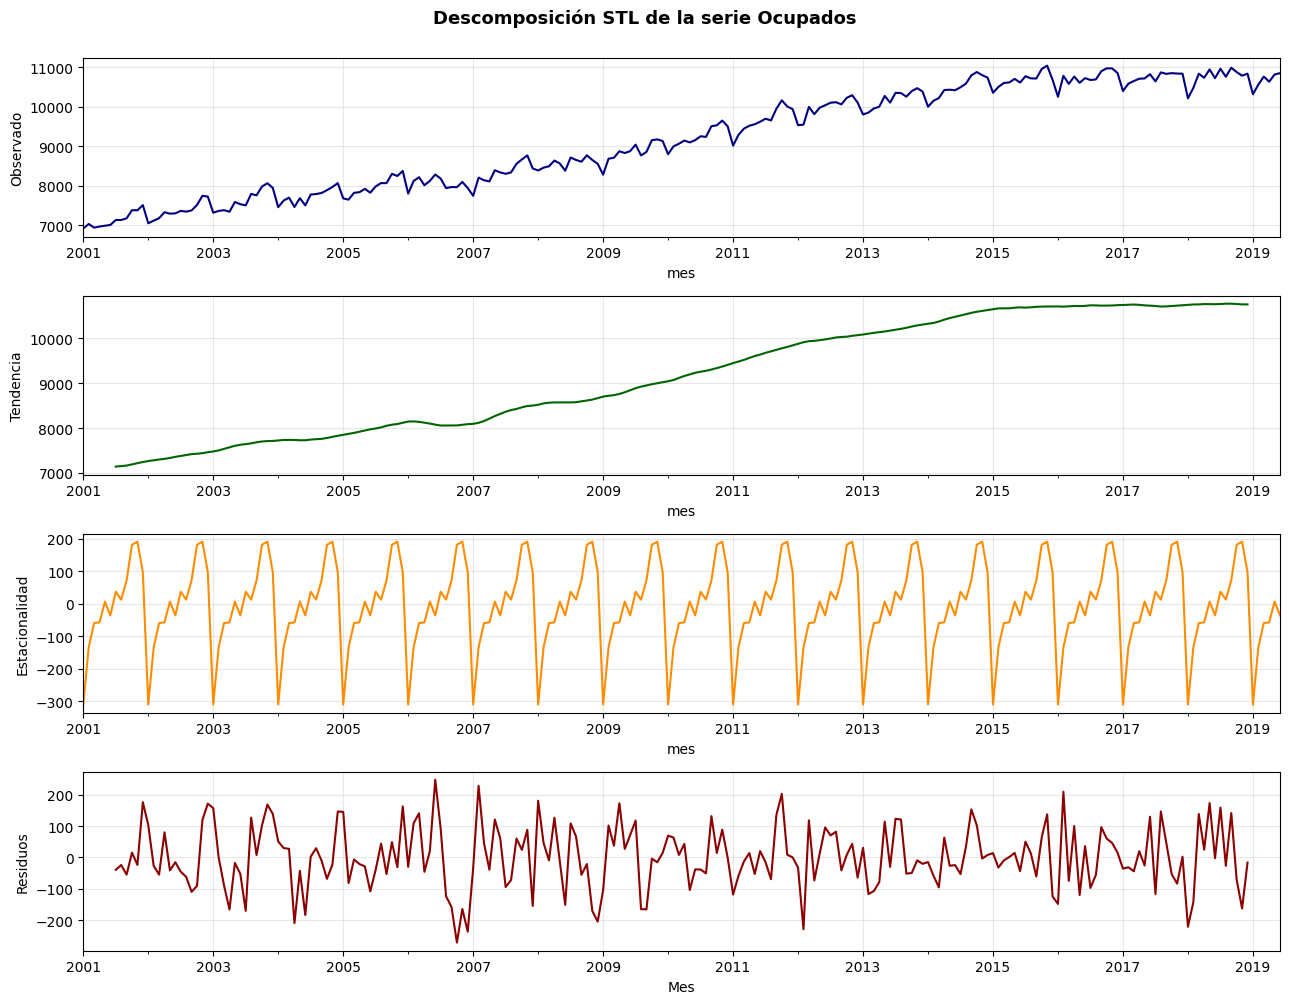


Presencia de tendencia: SÍ (crecimiento general)
Presencia de estacionalidad: SÍ (patrón anual recurrente)


In [15]:
# Exploración de la variable Ocupados
print("=" * 70)
print("DESCRIPCIÓN DE LA BASE DE DATOS - VARIABLE 'OCUPADOS'")
print("=" * 70)

ocupados = data[["Ocupados"]].copy()

print(f"\nPeríodo de datos: {ocupados.index[0].date()} a {ocupados.index[-1].date()}")
print(f"Total de observaciones: {len(ocupados)}")
print(f"Frecuencia: Mensual")
print(f"\nEstadísticas descriptivas:")
print(ocupados.describe())

# Gráfico de la serie completa
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(ocupados, linewidth=2, color='navy')
ax.set_title("Serie de Ocupados - 13 principales ciudades de Colombia", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Verificar presencia de tendencia y estacionalidad
from statsmodels.tsa.seasonal import seasonal_decompose

# Usar una periodicidad de 12 meses (anual)
descomposicion = seasonal_decompose(ocupados, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10))
descomposicion.observed.plot(ax=axes[0], color='navy')
axes[0].set_ylabel('Observado')
axes[0].grid(True, alpha=0.3)

descomposicion.trend.plot(ax=axes[1], color='darkgreen')
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

descomposicion.seasonal.plot(ax=axes[2], color='darkorange')
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

descomposicion.resid.plot(ax=axes[3], color='darkred')
axes[3].set_ylabel('Residuos')
axes[3].set_xlabel('Mes')
axes[3].grid(True, alpha=0.3)

plt.suptitle("Descomposición STL de la serie Ocupados", fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nPresencia de tendencia: SÍ (crecimiento general)")
print("Presencia de estacionalidad: SÍ (patrón anual recurrente)")

### 5.2 Protocolo de Validación: División Train/Test (Últimos 6 meses como Test)

PROTOCOLO DE VALIDACIÓN

Conjunto de entrenamiento: 216 observaciones
Período: 2001-01-01 a 2018-12-01

Conjunto de prueba: 6 observaciones (6 meses)
Período: 2019-01-01 a 2019-06-01


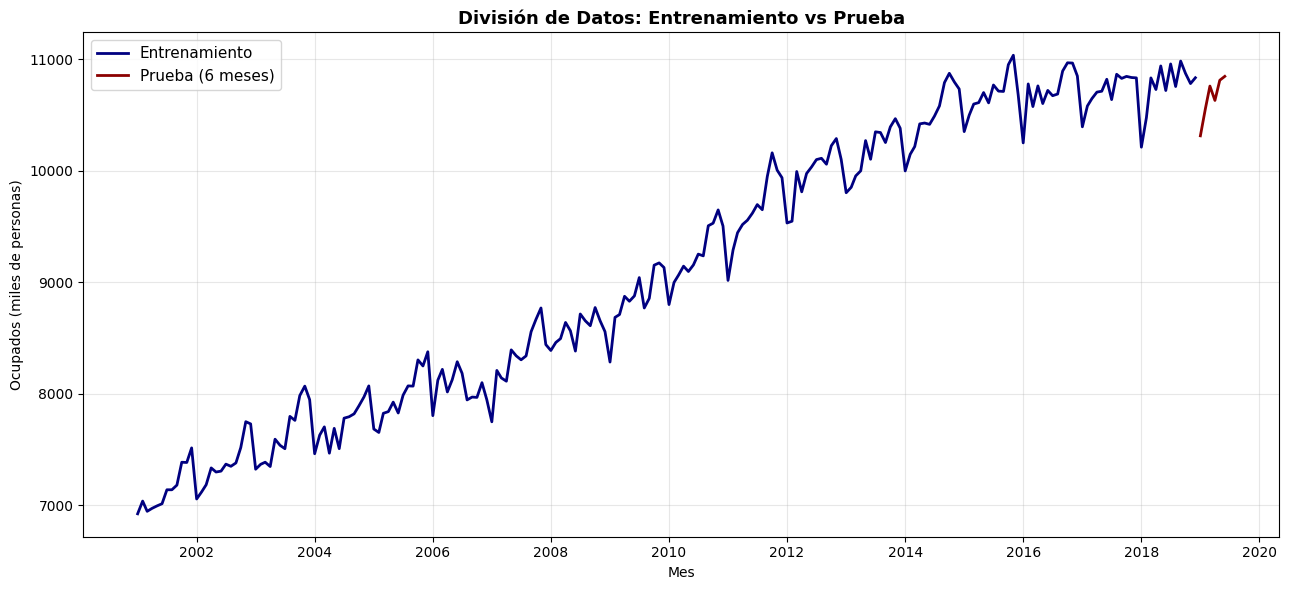

In [16]:
# División Train/Test con los últimos 6 meses como conjunto de prueba
test_size = 6
train_ocupados = ocupados[:-test_size]
test_ocupados = ocupados[-test_size:]

print("=" * 70)
print("PROTOCOLO DE VALIDACIÓN")
print("=" * 70)
print(f"\nConjunto de entrenamiento: {len(train_ocupados)} observaciones")
print(f"Período: {train_ocupados.index[0].date()} a {train_ocupados.index[-1].date()}")
print(f"\nConjunto de prueba: {len(test_ocupados)} observaciones (6 meses)")
print(f"Período: {test_ocupados.index[0].date()} a {test_ocupados.index[-1].date()}")

# Visualizar la división
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_ocupados.index, train_ocupados.values, linewidth=2, label='Entrenamiento', color='navy')
ax.plot(test_ocupados.index, test_ocupados.values, linewidth=2, label='Prueba (6 meses)', color='darkred')
ax.set_title("División de Datos: Entrenamiento vs Prueba", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Implementación de Modelos de Suavización Exponencial


MODELO 1: SUAVIZACIÓN EXPONENCIAL SIMPLE (SES)

Parámetro α (suavización de nivel): 0.633733
RMSE en conjunto de prueba: 253.6373


/Users/sebastiantoro/.pyenv/versions/3.11.8/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


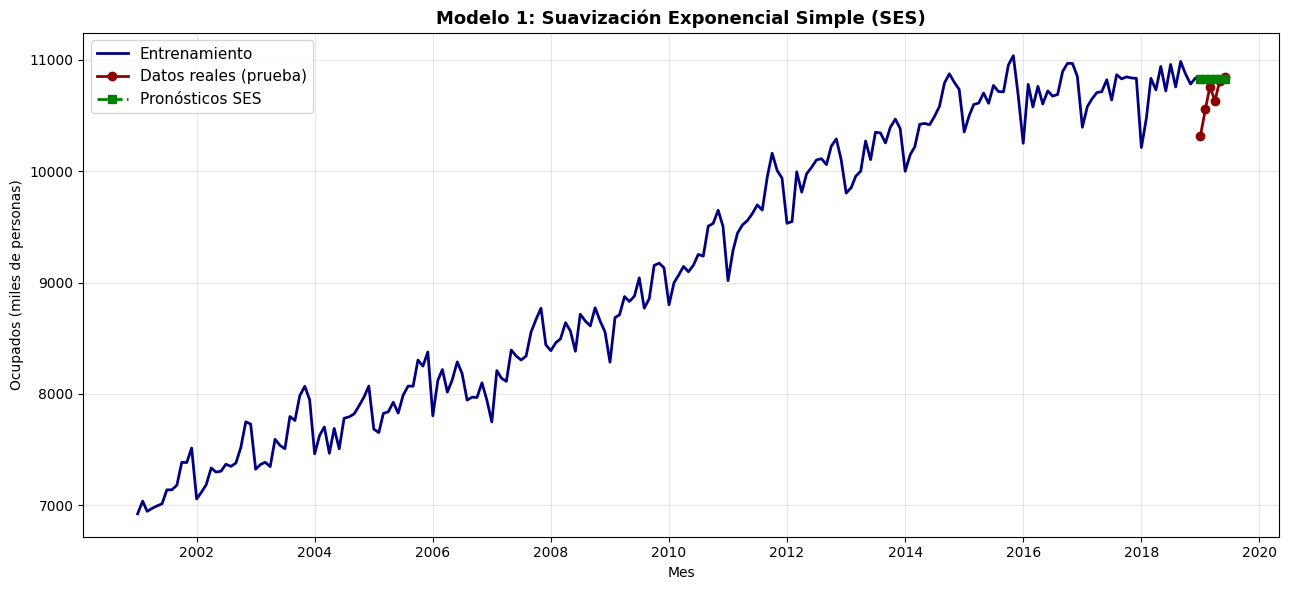

In [17]:
print("\n" + "=" * 70)
print("MODELO 1: SUAVIZACIÓN EXPONENCIAL SIMPLE (SES)")
print("=" * 70)

# Implementar SES
ets_ses = ETSModel(endog=train_ocupados["Ocupados"], error="add")
ets_ses_fit = ets_ses.fit()

# Pronósticos para el conjunto de prueba
pred_ses = ets_ses_fit.forecast(len(test_ocupados))

# Calcular RMSE
rmse_ses = np.sqrt(mean_squared_error(test_ocupados["Ocupados"], pred_ses.values))

# Extraer parámetros
alpha_ses = ets_ses_fit.params.get('smoothing_level', ets_ses_fit.alpha) if hasattr(ets_ses_fit, 'alpha') else ets_ses_fit.params.get('smoothing_level')

print(f"\nParámetro α (suavización de nivel): {alpha_ses:.6f}")
print(f"RMSE en conjunto de prueba: {rmse_ses:.4f}")

# Visualizar
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_ocupados.index, train_ocupados.values, linewidth=2, label='Entrenamiento', color='navy')
ax.plot(test_ocupados.index, test_ocupados.values, linewidth=2, label='Datos reales (prueba)', color='darkred', marker='o')
ax.plot(test_ocupados.index, pred_ses.values, linewidth=2, label='Pronósticos SES', color='green', linestyle='--', marker='s')
ax.set_title("Modelo 1: Suavización Exponencial Simple (SES)", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


MODELO 2: SUAVIZACIÓN EXPONENCIAL LINEAL DE HOLT

Parámetro α (suavización de nivel): 0.572583
Parámetro β (suavización de tendencia): 0.006405
RMSE en conjunto de prueba: 296.1552


/Users/sebastiantoro/.pyenv/versions/3.11.8/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


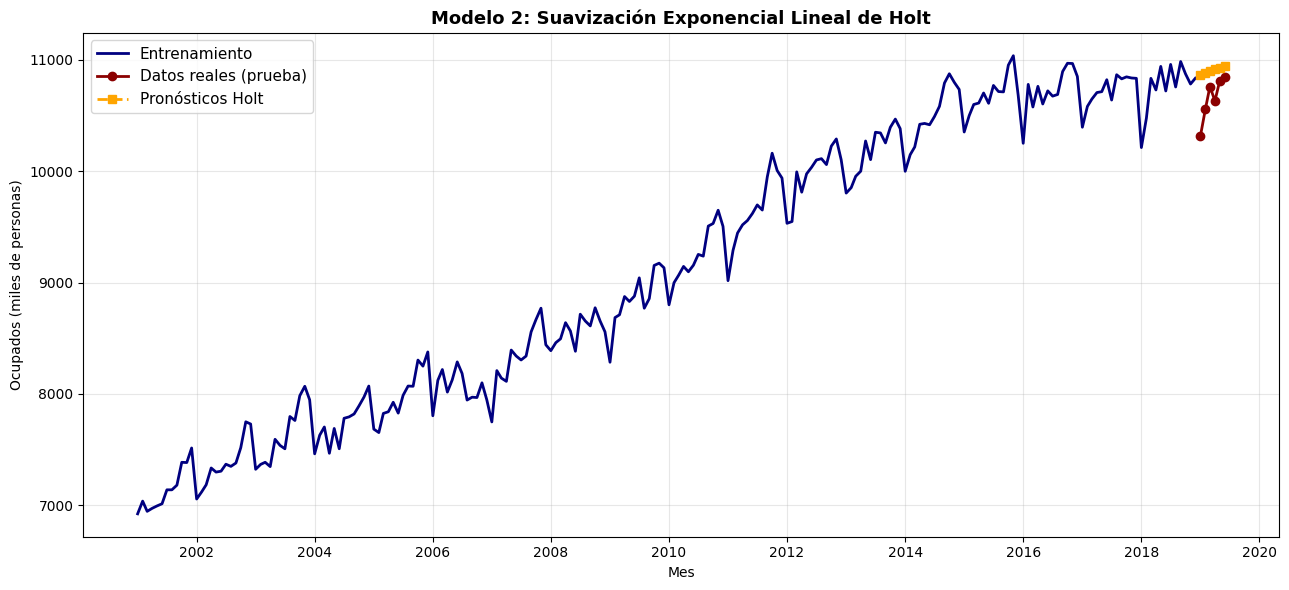

In [18]:
print("\n" + "=" * 70)
print("MODELO 2: SUAVIZACIÓN EXPONENCIAL LINEAL DE HOLT")
print("=" * 70)

# Implementar Holt (con tendencia)
ets_holt = ETSModel(endog=train_ocupados["Ocupados"], error="add", trend="add")
ets_holt_fit = ets_holt.fit()

# Pronósticos para el conjunto de prueba
pred_holt = ets_holt_fit.forecast(len(test_ocupados))

# Calcular RMSE
rmse_holt = np.sqrt(mean_squared_error(test_ocupados["Ocupados"], pred_holt.values))

# Extraer parámetros
alpha_holt = ets_holt_fit.params.get('smoothing_level', ets_holt_fit.alpha) if hasattr(ets_holt_fit, 'alpha') else ets_holt_fit.params.get('smoothing_level')
beta_holt = ets_holt_fit.params.get('smoothing_trend', ets_holt_fit.beta) if hasattr(ets_holt_fit, 'beta') else ets_holt_fit.params.get('smoothing_trend')

print(f"\nParámetro α (suavización de nivel): {alpha_holt:.6f}")
print(f"Parámetro β (suavización de tendencia): {beta_holt:.6f}")
print(f"RMSE en conjunto de prueba: {rmse_holt:.4f}")

# Visualizar
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_ocupados.index, train_ocupados.values, linewidth=2, label='Entrenamiento', color='navy')
ax.plot(test_ocupados.index, test_ocupados.values, linewidth=2, label='Datos reales (prueba)', color='darkred', marker='o')
ax.plot(test_ocupados.index, pred_holt.values, linewidth=2, label='Pronósticos Holt', color='orange', linestyle='--', marker='s')
ax.set_title("Modelo 2: Suavización Exponencial Lineal de Holt", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


MODELO 3A: HOLT-WINTERS ADITIVO

Parámetro α (suavización de nivel): 0.353298
Parámetro β (suavización de tendencia): 0.000035
Parámetro γ (suavización estacional): 0.297136
RMSE en conjunto de prueba: 74.3848


/Users/sebastiantoro/.pyenv/versions/3.11.8/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


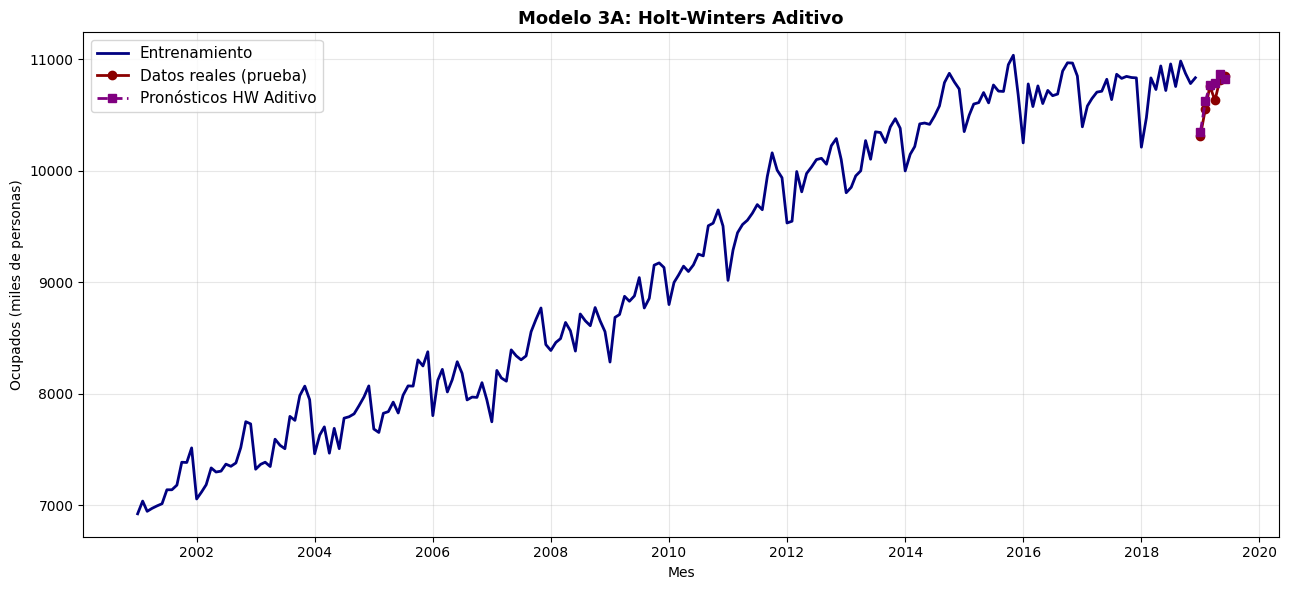

In [ ]:
print("\n" + "=" * 70)
print("MODELO 3A: HOLT-WINTERS ADITIVO")
print("=" * 70)

# Implementar Holt-Winters Aditivo (tendencia + estacionalidad)
ets_hw_add = ETSModel(endog=train_ocupados["Ocupados"], error="add", trend="add", seasonal="add")
ets_hw_add_fit = ets_hw_add.fit()

# Pronósticos para el conjunto de prueba
pred_hw_add = ets_hw_add_fit.forecast(len(test_ocupados))

# Calcular RMSE
rmse_hw_add = np.sqrt(mean_squared_error(test_ocupados["Ocupados"], pred_hw_add.values))

# Extraer parámetros
alpha_hw_add = ets_hw_add_fit.params.get('smoothing_level', ets_hw_add_fit.alpha) if hasattr(ets_hw_add_fit, 'alpha') else ets_hw_add_fit.params.get('smoothing_level')
beta_hw_add = ets_hw_add_fit.params.get('smoothing_trend', ets_hw_add_fit.beta) if hasattr(ets_hw_add_fit, 'beta') else ets_hw_add_fit.params.get('smoothing_trend')
gamma_hw_add = ets_hw_add_fit.params.get('smoothing_seasonal', ets_hw_add_fit.gamma) if hasattr(ets_hw_add_fit, 'gamma') else ets_hw_add_fit.params.get('smoothing_seasonal')

print(f"\nParámetro α (suavización de nivel): {alpha_hw_add:.6f}")
print(f"Parámetro β (suavización de tendencia): {beta_hw_add:.6f}")
print(f"Parámetro γ (suavización estacional): {gamma_hw_add:.6f}")
print(f"RMSE en conjunto de prueba: {rmse_hw_add:.4f}")

# Visualizar
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_ocupados.index, train_ocupados.values, linewidth=2, label='Entrenamiento', color='navy')
ax.plot(test_ocupados.index, test_ocupados.values, linewidth=2, label='Datos reales (prueba)', color='darkred', marker='o')
ax.plot(test_ocupados.index, pred_hw_add.values, linewidth=2, label='Pronósticos HW Aditivo', color='purple', linestyle='--', marker='s')
ax.set_title("Modelo 3A: Holt-Winters Aditivo", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


MODELO 3B: HOLT-WINTERS MULTIPLICATIVO

Parámetro α (suavización de nivel): 0.559443
Parámetro β (suavización de tendencia): 0.000663
Parámetro γ (suavización estacional): 0.000044
RMSE en conjunto de prueba: 61.9884


/Users/sebastiantoro/.pyenv/versions/3.11.8/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


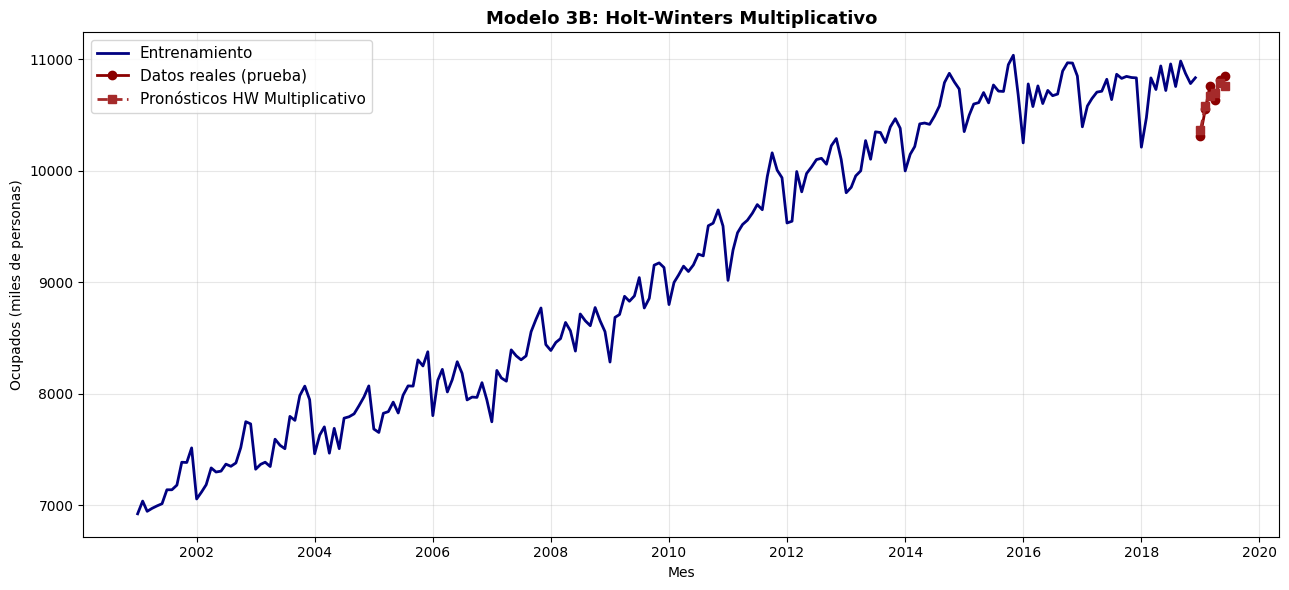

In [9]:
print("\n" + "=" * 70)
print("MODELO 3B: HOLT-WINTERS MULTIPLICATIVO")
print("=" * 70)

# Implementar Holt-Winters Multiplicativo
ets_hw_mul = ETSModel(endog=train_ocupados["Ocupados"], error="mul", trend="add", seasonal="mul")
ets_hw_mul_fit = ets_hw_mul.fit()

# Pronósticos para el conjunto de prueba
pred_hw_mul = ets_hw_mul_fit.forecast(len(test_ocupados))

# Calcular RMSE
rmse_hw_mul = np.sqrt(mean_squared_error(test_ocupados["Ocupados"], pred_hw_mul.values))

# Extraer parámetros
alpha_hw_mul = ets_hw_mul_fit.params.get('smoothing_level', ets_hw_mul_fit.alpha) if hasattr(ets_hw_mul_fit, 'alpha') else ets_hw_mul_fit.params.get('smoothing_level')
beta_hw_mul = ets_hw_mul_fit.params.get('smoothing_trend', ets_hw_mul_fit.beta) if hasattr(ets_hw_mul_fit, 'beta') else ets_hw_mul_fit.params.get('smoothing_trend')
gamma_hw_mul = ets_hw_mul_fit.params.get('smoothing_seasonal', ets_hw_mul_fit.gamma) if hasattr(ets_hw_mul_fit, 'gamma') else ets_hw_mul_fit.params.get('smoothing_seasonal')

print(f"\nParámetro α (suavización de nivel): {alpha_hw_mul:.6f}")
print(f"Parámetro β (suavización de tendencia): {beta_hw_mul:.6f}")
print(f"Parámetro γ (suavización estacional): {gamma_hw_mul:.6f}")
print(f"RMSE en conjunto de prueba: {rmse_hw_mul:.4f}")

# Visualizar
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_ocupados.index, train_ocupados.values, linewidth=2, label='Entrenamiento', color='navy')
ax.plot(test_ocupados.index, test_ocupados.values, linewidth=2, label='Datos reales (prueba)', color='darkred', marker='o')
ax.plot(test_ocupados.index, pred_hw_mul.values, linewidth=2, label='Pronósticos HW Multiplicativo', color='brown', linestyle='--', marker='s')
ax.set_title("Modelo 3B: Holt-Winters Multiplicativo", fontsize=13, fontweight='bold')
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupados (miles de personas)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Tabla Comparativa de Resultados

In [10]:
print("\n" + "=" * 100)
print("TABLA COMPARATIVA DE MODELOS DE SUAVIZACIÓN EXPONENCIAL")
print("=" * 100)

# Crear dataframe comparativo
resultados_modelos = pd.DataFrame({
    'Modelo': [
        'SES (Simple)',
        'Holt (Lineal)',
        'HW Aditivo',
        'HW Multiplicativo'
    ],
    'α (Nivel)': [
        f"{alpha_ses:.6f}",
        f"{alpha_holt:.6f}",
        f"{alpha_hw_add:.6f}",
        f"{alpha_hw_mul:.6f}"
    ],
    'β (Tendencia)': [
        '—',
        f"{beta_holt:.6f}",
        f"{beta_hw_add:.6f}",
        f"{beta_hw_mul:.6f}"
    ],
    'γ (Estacional)': [
        '—',
        '—',
        f"{gamma_hw_add:.6f}",
        f"{gamma_hw_mul:.6f}"
    ],
    'RMSE (Test)': [
        f"{rmse_ses:.4f}",
        f"{rmse_holt:.4f}",
        f"{rmse_hw_add:.4f}",
        f"{rmse_hw_mul:.4f}"
    ]
})

print("\n")
print(resultados_modelos.to_string(index=False))
print("\n" + "=" * 100)

# Identificar el mejor modelo
rmse_values = [rmse_ses, rmse_holt, rmse_hw_add, rmse_hw_mul]
model_names = ['SES', 'Holt', 'HW Aditivo', 'HW Multiplicativo']
best_idx = np.argmin(rmse_values)
best_model = model_names[best_idx]
best_rmse = rmse_values[best_idx]

print(f"\n✓ MEJOR MODELO: {best_model} con RMSE = {best_rmse:.4f}")
print("=" * 100)


TABLA COMPARATIVA DE MODELOS DE SUAVIZACIÓN EXPONENCIAL


           Modelo α (Nivel) β (Tendencia) γ (Estacional) RMSE (Test)
     SES (Simple)  0.633733             —              —    253.6373
    Holt (Lineal)  0.572583      0.006405              —    296.1552
       HW Aditivo  0.353298      0.000035       0.297136     74.3848
HW Multiplicativo  0.559443      0.000663       0.000044     61.9884


✓ MEJOR MODELO: HW Multiplicativo con RMSE = 61.9884


### 5.5 Pronósticos Finales para los Próximos 6 Meses (Usando Modelo Ganador)

In [11]:
# Seleccionar el mejor modelo y entrenar con TODO el dataset
print("\n" + "=" * 100)
print(f"PRONÓSTICOS FINALES - MODELO GANADOR: {best_model.upper()}")
print("=" * 100)

# Definir parámetros del modelo ganador
if best_model == 'SES':
    print(f"\nEntrenando con SES en TODO el dataset...")
    final_model = ETSModel(endog=ocupados["Ocupados"], error="add")
    final_fit = final_model.fit()
    alpha_final = final_fit.params.get('smoothing_level', final_fit.alpha) if hasattr(final_fit, 'alpha') else final_fit.params.get('smoothing_level')
    beta_final = None
    gamma_final = None
    
elif best_model == 'Holt':
    print(f"\nEntrenando con Holt en TODO el dataset...")
    final_model = ETSModel(endog=ocupados["Ocupados"], error="add", trend="add")
    final_fit = final_model.fit()
    alpha_final = final_fit.params.get('smoothing_level', final_fit.alpha) if hasattr(final_fit, 'alpha') else final_fit.params.get('smoothing_level')
    beta_final = final_fit.params.get('smoothing_trend', final_fit.beta) if hasattr(final_fit, 'beta') else final_fit.params.get('smoothing_trend')
    gamma_final = None
    
elif best_model == 'HW Aditivo':
    print(f"\nEntrenando con Holt-Winters Aditivo en TODO el dataset...")
    final_model = ETSModel(endog=ocupados["Ocupados"], error="add", trend="add", seasonal="add")
    final_fit = final_model.fit()
    alpha_final = final_fit.params.get('smoothing_level', final_fit.alpha) if hasattr(final_fit, 'alpha') else final_fit.params.get('smoothing_level')
    beta_final = final_fit.params.get('smoothing_trend', final_fit.beta) if hasattr(final_fit, 'beta') else final_fit.params.get('smoothing_trend')
    gamma_final = final_fit.params.get('smoothing_seasonal', final_fit.gamma) if hasattr(final_fit, 'gamma') else final_fit.params.get('smoothing_seasonal')
    
else:  # HW Multiplicativo
    print(f"\nEntrenando con Holt-Winters Multiplicativo en TODO el dataset...")
    final_model = ETSModel(endog=ocupados["Ocupados"], error="mul", trend="add", seasonal="mul")
    final_fit = final_model.fit()
    alpha_final = final_fit.params.get('smoothing_level', final_fit.alpha) if hasattr(final_fit, 'alpha') else final_fit.params.get('smoothing_level')
    beta_final = final_fit.params.get('smoothing_trend', final_fit.beta) if hasattr(final_fit, 'beta') else final_fit.params.get('smoothing_trend')
    gamma_final = final_fit.params.get('smoothing_seasonal', final_fit.gamma) if hasattr(final_fit, 'gamma') else final_fit.params.get('smoothing_seasonal')

print(f"✓ Modelo ajustado exitosamente con TODO el dataset ({len(ocupados)} observaciones)")
print(f"\nParámetros finales:")
print(f"  α (Nivel): {alpha_final:.6f}")
if beta_final is not None:
    print(f"  β (Tendencia): {beta_final:.6f}")
if gamma_final is not None:
    print(f"  γ (Estacional): {gamma_final:.6f}")

# Generar pronósticos para los próximos 6 meses
forecast_steps = 6
forecast_final = final_fit.forecast(steps=forecast_steps)

# Crear índice de fechas para los pronósticos
last_date = ocupados.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')

# Crear dataframe con los pronósticos
pronosticos_df = pd.DataFrame({
    'Fecha': future_dates,
    'Pronóstico': forecast_final.values
})
pronosticos_df.set_index('Fecha', inplace=True)

print("\n" + "=" * 70)
print("PRONÓSTICOS PARA LOS PRÓXIMOS 6 MESES")
print("=" * 70)
print(pronosticos_df.to_string())
print("=" * 70)


PRONÓSTICOS FINALES - MODELO GANADOR: HW MULTIPLICATIVO

Entrenando con Holt-Winters Multiplicativo en TODO el dataset...
✓ Modelo ajustado exitosamente con TODO el dataset (222 observaciones)

Parámetros finales:
  α (Nivel): 0.558890
  β (Tendencia): 0.000492
  γ (Estacional): 0.000044

PRONÓSTICOS PARA LOS PRÓXIMOS 6 MESES
              Pronóstico
Fecha                   
2019-07-01  10925.938994
2019-08-01  10918.307184
2019-09-01  11005.134157
2019-10-01  11163.883148
2019-11-01  11202.407610
2019-12-01  11117.660172


/Users/sebastiantoro/.pyenv/versions/3.11.8/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


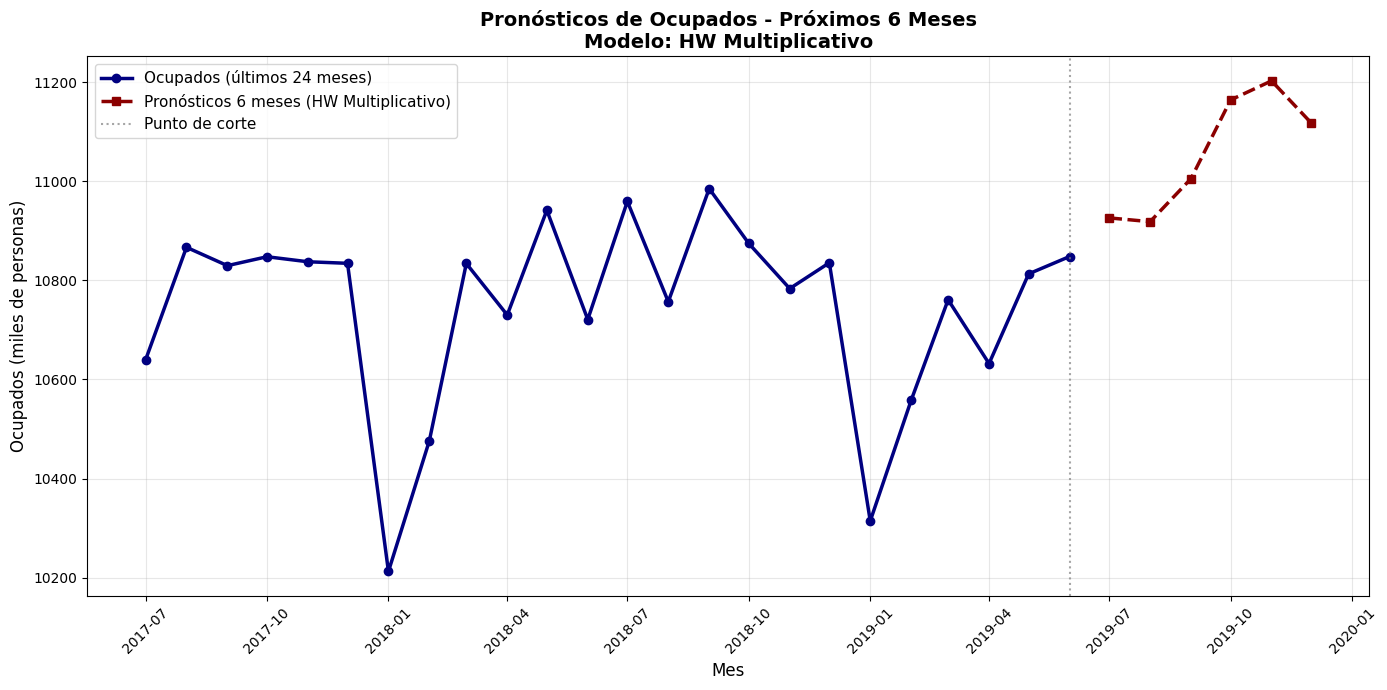

In [12]:
# Visualizar serie histórica + pronósticos
fig, ax = plt.subplots(figsize=(14, 7))

# Últimos 24 meses de la serie histórica para mejor visualización
ax.plot(ocupados.index[-24:], ocupados.values[-24:], linewidth=2.5, label='Ocupados (últimos 24 meses)', color='navy', marker='o')
ax.plot(pronosticos_df.index, pronosticos_df.values, linewidth=2.5, label=f'Pronósticos 6 meses ({best_model})', color='darkred', marker='s', linestyle='--')

ax.axvline(x=ocupados.index[-1], color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Punto de corte')
ax.set_title(f"Pronósticos de Ocupados - Próximos 6 Meses\nModelo: {best_model}", fontsize=14, fontweight='bold')
ax.set_xlabel("Mes", fontsize=12)
ax.set_ylabel("Ocupados (miles de personas)", fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.6 Recomendaciones y Limitaciones de los Pronósticos

In [13]:
print("\n" + "=" * 100)
print("LIMITACIONES DE LOS PRONÓSTICOS")
print("=" * 100)

limitaciones = """
1. **Horizonte de Pronóstico Corto (6 meses):**
   - Los pronósticos a corto plazo son más confiables que a largo plazo
   - Se asume que los patrones históricos se mantienen en el futuro próximo
   - Cambios estructurales en el mercado laboral podrían reducir la precisión

2. **Dependencia de Patrones Históricos:**
   - El modelo se basa en la relación temporal observada en los datos
   - Shocks externos (crisis económicas, pandemia, reformas laborales) no son capturados
   - La estacionariedad de la serie asume volatilidad constante

3. **Falta de Variables Exógenas:**
   - No se incluyen variables explicativas (crecimiento PIB, políticas fiscales, inflación)
   - Eventos macroeconómicos no previstos podrían afectar significativamente el resultado

4. **Calidad de los Datos:**
   - Se asume que los datos son precisos y completos
   - Cambios en metodología de recolección de datos podrían afectar la serie

5. **Validación con Período Limitado:**
   - El RMSE se calculó solo con 6 observaciones de prueba
   - Muestras pequeñas pueden llevar a estimaciones de error poco estables

6. **Pérdida de Información Prospectiva:**
   - El modelo no incorpora expectativas futuras de analistas o agentes económicos
   - No captura tendencias de mediano plazo relacionadas con ciclos económicos
"""

print(limitaciones)

print("\n" + "=" * 100)
print("RECOMENDACIONES PARA EL USO DE LOS PRONÓSTICOS")
print("=" * 100)

recomendaciones = """
1. **Usar como Referencia Base, No como Predicción Exacta:**
   - Los pronósticos deben servir como punto de partida para análisis adicionales
   - Complementar con criterio experto y análisis cualitativo del mercado laboral

2. **Monitoreo Continuo:**
   - Comparar los valores reales con los pronósticos conforme se disponga de nueva información
   - Actualizar el modelo mensualmente con datos recientes

3. **Intervalos de Confianza:**
   - Considerar márgenes de error del ±{best_rmse:.4f} miles de personas
   - Los verdaderos valores podrían estar fuera de los puntos estimados

4. **Análisis de Escenarios:**
   - Desarrollar pronósticos alternativos bajo diferentes supuestos económicos
   - Evaluar casos de optimismo, pesimismo y base

5. **Validación Cruzada:**
   - A medida que se observe el desempeño real, comparar con otros métodos
   - Si el desempeño es pobre, explorar especificaciones alternativas

6. **Comunicación de Incertidumbre:**
   - Explicitar los supuestos del modelo al comunicar los resultados
   - Enfatizar que es un pronóstico probabilístico, no determinístico

7. **Integración con Información Cualitativa:**
   - Combinar con encuestas de expectativas empresariales
   - Considerar noticias de política laboral y condiciones macroeconómicas
"""

print(recomendaciones)
print("\n" + "=" * 100)


LIMITACIONES DE LOS PRONÓSTICOS

1. **Horizonte de Pronóstico Corto (6 meses):**
   - Los pronósticos a corto plazo son más confiables que a largo plazo
   - Se asume que los patrones históricos se mantienen en el futuro próximo
   - Cambios estructurales en el mercado laboral podrían reducir la precisión

2. **Dependencia de Patrones Históricos:**
   - El modelo se basa en la relación temporal observada en los datos
   - Shocks externos (crisis económicas, pandemia, reformas laborales) no son capturados
   - La estacionariedad de la serie asume volatilidad constante

3. **Falta de Variables Exógenas:**
   - No se incluyen variables explicativas (crecimiento PIB, políticas fiscales, inflación)
   - Eventos macroeconómicos no previstos podrían afectar significativamente el resultado

4. **Calidad de los Datos:**
   - Se asume que los datos son precisos y completos
   - Cambios en metodología de recolección de datos podrían afectar la serie

5. **Validación con Período Limitado:**
   - 